# 03 · Modelado y evaluación

**Proyecto ML — Predicción del precio de gafas graduadas (caso óptica).**

Este notebook recoge el dataset limpio + features generadas en el `02_LimpiezaEDA` y entrena varios modelos para predecir `precio`.

## Decisiones conceptuales heredadas
- **Lineales** se entrenan con `log_precio` (mejor para distribuciones asimétricas) y vuelven a € con `expm1` antes de medir métricas.
- **Árboles** se entrenan con `precio` directo (insensibles a la escala del target).
- **Métricas SIEMPRE en €**, así son interpretables para negocio.
- `modelo` es identificador, no feature.
- Renombramos `tier` → `gama_marca` y `segmento` → `segmento_comercial` para legibilidad.

## Estructura
1. Setup y carga.
2. Definición de columnas.
3. Métricas y utilidades.
4. Preprocesado (ColumnTransformer).
5. Baselines.
6. Comparación principal por familias.
7. Ablaciones de variables (bloques A, B, C, D).
8. Multicolinealidad y VIF.
9. Selección final + GridSearch.
10. Entrenamiento final y evaluación en test.
11. Diagnósticos e interpretación.
12. Conclusiones.

## 1. Setup y carga

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\juan_\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

ROOT  = Path.cwd().parent
TRAIN = ROOT / 'data' / 'train' / 'train.csv'
TEST  = ROOT / 'data' / 'test'  / 'test.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV_SPLITS    = 5

In [3]:
train_df = pd.read_csv(TRAIN)
test_df  = pd.read_csv(TEST)

print(f'train: {train_df.shape}')
print(f'test:  {test_df.shape}')
train_df.head(2)

train: (2296, 31)
test:  (574, 31)


,modelo,marca,genero,material_montura,forma,tipo_montura,color,talla,ancho_lente,ancho_puente,largo_varilla,peso,gama_marca,segmento_comercial,pais_origen,precio_min,precio_max,categoria_material,gama_material,peso_relativo,aspect_ratio,area_aprox,densidad,ancho_total,montura_completa,es_unisex,color_basico,material_eco,precio_medio_marca,precio,log_precio
0,Twitch 3.0 NAO32302 46,Nano Vista,Niños,Pasta,Rectangulares,Montura completa,azul,XS,46.0,14.0,136.0,80.0,gama_media,marca_blanca_OEM,España/Italia,40.0,100.0,acetato,media,ligero,0.338235,644.0,0.124224,106.0,1,0,0,0,70.0,99.9,4.614130
1,2625 200 16 55,Mexx,Hombre,Pasta,Rectangulares,Montura completa,marron,M,55.0,16.0,145.0,160.0,gama_media,moda_casual,Países Bajos,60.0,130.0,acetato,media,ligero,0.379310,880.0,0.181818,126.0,1,0,1,0,95.0,129.9,4.874434


In [4]:
# Verificación de columnas críticas
obligatorias = ['precio', 'log_precio']
esperadas    = ['modelo', 'gama_marca', 'segmento_comercial']

for col in obligatorias:
    assert col in train_df.columns, f'Falta columna obligatoria: {col!r}'
    assert col in test_df.columns,  f'Falta columna obligatoria en test: {col!r}'

for col in esperadas:
    estado = '✓' if col in train_df.columns else '✗ (no encontrada, se manejará)'
    print(f'  {col:<22} {estado}')

  modelo                 ✓
  gama_marca             ✓
  segmento_comercial     ✓


## 2. Definición de conjuntos de columnas

In [5]:
ID_COL  = 'modelo'
TARGETS = ['precio', 'log_precio']

def existing(cols, df):
    """Devuelve solo las columnas que existen realmente en df."""
    return [c for c in cols if c in df.columns]

# Listas canónicas (incluyen opcionales)
CAT_CANONICAS = [
    'marca', 'genero', 'material_montura', 'forma', 'tipo_montura',
    'color', 'talla',
    'gama_marca', 'segmento_comercial', 'pais_origen',
    'categoria_material', 'gama_material', 'peso_relativo',
]
NUM_CANONICAS = [
    'ancho_lente', 'ancho_puente', 'largo_varilla', 'peso',
    'precio_min', 'precio_max', 'precio_medio_marca',
    'aspect_ratio', 'area_aprox', 'densidad', 'ancho_total',
    'montura_completa', 'es_unisex', 'color_basico', 'material_eco',
]

CAT_COLS = existing(CAT_CANONICAS, train_df)
NUM_COLS = existing(NUM_CANONICAS, train_df)

FEATURES = CAT_COLS + NUM_COLS
assert ID_COL not in FEATURES, 'modelo no debe ir en X'
for t in TARGETS:
    assert t not in FEATURES, f'{t} no debe ir en X'

print(f'Categóricas ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Numéricas   ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Total features: {len(FEATURES)}')

Categóricas (13): ['marca', 'genero', 'material_montura', 'forma', 'tipo_montura', 'color', 'talla', 'gama_marca', 'segmento_comercial', 'pais_origen', 'categoria_material', 'gama_material', 'peso_relativo']
Numéricas   (15): ['ancho_lente', 'ancho_puente', 'largo_varilla', 'peso', 'precio_min', 'precio_max', 'precio_medio_marca', 'aspect_ratio', 'area_aprox', 'densidad', 'ancho_total', 'montura_completa', 'es_unisex', 'color_basico', 'material_eco']
Total features: 28


In [6]:
X_train = train_df[FEATURES].copy()
y_train = train_df['precio'].copy()

X_test  = test_df[FEATURES].copy()
y_test  = test_df['precio'].copy()

print(f'X_train: {X_train.shape}  ·  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  ·  y_test:  {y_test.shape}')
print(f'\nRango de precio en train: {y_train.min():.2f} € — {y_train.max():.2f} €')

X_train: (2296, 28)  ·  y_train: (2296,)
X_test:  (574, 28)  ·  y_test:  (574,)

Rango de precio en train: 18.89 € — 479.90 €


## 3. Métricas y utilidades

Funciones reutilizables. Importante: cuando un modelo se entrena con `log_precio` (vía `TransformedTargetRegressor`), la predicción que devuelve `.predict()` ya viene en € (back-transform automático). Por eso podemos calcular métricas en € directamente sobre `predict(X)` independientemente de cómo se entrenó internamente.

In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def evaluate_model_cv(model, X, y, cv=CV_SPLITS, label='model'):
    """CV en train. Devuelve dict con MAE, RMSE, R², MAPE en €.
    Importante: y siempre en €. El modelo gestiona internamente la transformación si la lleva."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    maes, rmses, r2s, mapes = [], [], [], []
    for tr_idx, va_idx in kf.split(X):
        m = clone_model(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        y_pred = m.predict(X.iloc[va_idx])
        y_true = y.iloc[va_idx]
        maes.append(mean_absolute_error(y_true, y_pred))
        rmses.append(rmse(y_true, y_pred))
        r2s.append(r2_score(y_true, y_pred))
        mapes.append(mape(y_true, y_pred))
    return {
        'modelo':  label,
        'MAE_€':   np.mean(maes),
        'RMSE_€':  np.mean(rmses),
        'R²':      np.mean(r2s),
        'MAPE_%':  np.mean(mapes),
        'MAE_std': np.std(maes),
    }

def clone_model(model):
    """Helper: clona el estimator para no acumular fits entre folds."""
    from sklearn.base import clone
    return clone(model)


def evaluate_on_test(model, X_train, y_train, X_test, y_test, label='model'):
    """Entrena con todo train y evalúa en test (UNA sola vez al final)."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'modelo':   label,
        'MAE_€':    mean_absolute_error(y_test, y_pred),
        'RMSE_€':   rmse(y_test, y_pred),
        'R²':       r2_score(y_test, y_pred),
        'MAPE_%':   mape(y_test, y_pred),
    }, y_pred


print('Funciones de métricas y CV listas.')

Funciones de métricas y CV listas.


## 4. Preprocesado

Dos preprocessors distintos según familia:
- **Lineal**: imputación + StandardScaler (numéricas) + OneHot (categóricas).
- **Árboles**: imputación + OneHot (categóricas). Sin escalado (no aporta y mantiene interpretabilidad).

Función `build_preprocessor` que acepta listas custom de num/cat → reutilizable en ablaciones.

In [8]:
def build_preprocessor(num_cols, cat_cols, kind='linear'):
    """Construye un ColumnTransformer.
    kind: 'linear' (escala numéricas) o 'tree' (no escala).
    """
    if kind == 'linear':
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ])
    else:
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ])

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    transformers = []
    if num_cols:
        transformers.append(('num', num_pipe, num_cols))
    if cat_cols:
        transformers.append(('cat', cat_pipe, cat_cols))

    return ColumnTransformer(transformers, remainder='drop', verbose_feature_names_out=False)


# Smoke test: construir uno y aplicarlo
_pre = build_preprocessor(NUM_COLS, CAT_COLS, kind='linear')
_X_t = _pre.fit_transform(X_train.head(50))
print(f'Preprocesador OK. Shape tras transformación: {_X_t.shape}')

Preprocesador OK. Shape tras transformación: (50, 106)


## 5. Baselines

Defino los modelos que se compararán. Los lineales van envueltos en `TransformedTargetRegressor` para entrenar internamente sobre `log(1+precio)` y predecir en €.

In [9]:
def make_linear_pipeline(estimator, num_cols=NUM_COLS, cat_cols=CAT_COLS):
    """Pipeline lineal: preprocessor + estimator. Envuelto en TransformedTargetRegressor (log)."""
    inner = Pipeline([
        ('prep', build_preprocessor(num_cols, cat_cols, kind='linear')),
        ('m',    estimator),
    ])
    return TransformedTargetRegressor(
        regressor=inner,
        func=np.log1p,
        inverse_func=np.expm1,
    )

def make_tree_pipeline(estimator, num_cols=NUM_COLS, cat_cols=CAT_COLS):
    """Pipeline árboles: preprocessor + estimator (target en € directo)."""
    return Pipeline([
        ('prep', build_preprocessor(num_cols, cat_cols, kind='tree')),
        ('m',    estimator),
    ])


MODELS = {
    'Dummy (mean)':       make_tree_pipeline(DummyRegressor(strategy='mean')),
    'LinearReg (log)':    make_linear_pipeline(LinearRegression()),
    'Ridge (log)':        make_linear_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'Lasso (log)':        make_linear_pipeline(Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE)),
    'ElasticNet (log)':   make_linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE)),
    'RandomForest':       make_tree_pipeline(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    'HistGradientBoost':  make_tree_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
}

print(f'{len(MODELS)} modelos definidos.')

7 modelos definidos.


## 6. Comparación principal por familias

CV (k=5) sobre train. Métricas reportadas en €.

In [10]:
resultados_cv = []
for nombre, modelo in MODELS.items():
    res = evaluate_model_cv(modelo, X_train, y_train, label=nombre)
    resultados_cv.append(res)
    print(f'  {nombre:<22} MAE={res["MAE_€"]:6.2f} €  RMSE={res["RMSE_€"]:6.2f} €  R²={res["R²"]:.3f}')

  Dummy (mean)           MAE= 58.40 €  RMSE= 72.14 €  R²=-0.001
  LinearReg (log)        MAE= 20.89 €  RMSE= 29.80 €  R²=0.829
  Ridge (log)            MAE= 20.92 €  RMSE= 29.62 €  R²=0.831
  Lasso (log)            MAE= 22.18 €  RMSE= 30.75 €  R²=0.818
  ElasticNet (log)       MAE= 21.48 €  RMSE= 30.06 €  R²=0.826
  RandomForest           MAE= 18.22 €  RMSE= 27.71 €  R²=0.852
  HistGradientBoost      MAE= 19.64 €  RMSE= 28.68 €  R²=0.841


In [11]:
tabla_cv = (pd.DataFrame(resultados_cv)
            .set_index('modelo')
            .round(2)
            .sort_values('MAE_€'))
tabla_cv

,MAE_€,RMSE_€,R²,MAPE_%,MAE_std
modelo,,,,,
RandomForest,18.22,27.71,0.85,16.00,0.72
HistGradientBoost,19.64,28.68,0.84,17.39,1.20
LinearReg (log),20.89,29.80,0.83,17.66,1.02
Ridge (log),20.92,29.62,0.83,17.69,0.92
ElasticNet (log),21.48,30.06,0.83,18.22,0.98
Lasso (log),22.18,30.75,0.82,18.83,0.99
Dummy (mean),58.40,72.14,-0.00,53.64,0.76


## 7. Ablaciones de variables

Cuatro bloques con preguntas concretas. Cada bloque se evalúa con un modelo representativo de cada familia (Ridge para lineal, HistGradientBoosting para árboles), no con todos — eso explotaría combinatoriamente.

Helper común:

In [12]:
def ablate(num_cols, cat_cols, label):
    """Evalúa una configuración (num+cat) con Ridge (log) y HGB (€) en CV. Devuelve dos filas."""
    lineal = make_linear_pipeline(
        Ridge(alpha=1.0, random_state=RANDOM_STATE),
        num_cols=num_cols, cat_cols=cat_cols,
    )
    arbol = make_tree_pipeline(
        RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        num_cols=num_cols, cat_cols=cat_cols,
    )
    X_sub = train_df[num_cols + cat_cols]
    res_l = evaluate_model_cv(lineal, X_sub, y_train, label=f'{label} | Ridge')
    res_t = evaluate_model_cv(arbol,  X_sub, y_train, label=f'{label} | RF')
    return [res_l, res_t]

### Bloque A. Variables de precio de marca

`precio_min`, `precio_max` y `precio_medio_marca` están casi perfectamente correlacionadas. Probamos:
- A1: solo `precio_medio_marca`
- A2: `precio_min` + `precio_max`
- A3: las tres

**Pregunta:** ¿basta con `precio_medio_marca`?

In [13]:
# Resto de features iguales en todos los casos del bloque A
_resto_num = [c for c in NUM_COLS if c not in ('precio_min', 'precio_max', 'precio_medio_marca')]

filas_A = []
filas_A += ablate(_resto_num + ['precio_medio_marca'],            CAT_COLS, 'A1: solo precio_medio')
filas_A += ablate(_resto_num + ['precio_min', 'precio_max'],      CAT_COLS, 'A2: min+max')
filas_A += ablate(_resto_num + ['precio_min', 'precio_max', 'precio_medio_marca'], CAT_COLS, 'A3: las 3')

tabla_A = pd.DataFrame(filas_A).set_index('modelo').round(2).sort_values('MAE_€')
tabla_A

,MAE_€,RMSE_€,R²,MAPE_%,MAE_std
modelo,,,,,
A1: solo precio_medio | RF,18.20,27.67,0.85,15.98,0.70
A2: min+max | RF,18.20,27.72,0.85,15.97,0.73
A3: las 3 | RF,18.23,27.72,0.85,16.01,0.68
A1: solo precio_medio | Ridge,20.92,29.63,0.83,17.69,0.92
A2: min+max | Ridge,20.92,29.63,0.83,17.70,0.92
A3: las 3 | Ridge,20.92,29.62,0.83,17.69,0.92


### Bloque B. Variables geométricas

`ancho_total = 2·ancho_lente + ancho_puente` está correlacionado con sus componentes.
- B1: `ancho_lente` + `ancho_puente` + `largo_varilla` (originales)
- B2: `ancho_total` + `largo_varilla` (compactas)
- B3: todas

**Pregunta:** ¿`ancho_total` simplifica o solo añade redundancia?

In [14]:
_geo_cols = ('ancho_lente', 'ancho_puente', 'largo_varilla', 'ancho_total')
_resto_num = [c for c in NUM_COLS if c not in _geo_cols]

filas_B = []
filas_B += ablate(_resto_num + ['ancho_lente', 'ancho_puente', 'largo_varilla'], CAT_COLS, 'B1: originales')
filas_B += ablate(_resto_num + ['ancho_total', 'largo_varilla'],                 CAT_COLS, 'B2: ancho_total')
filas_B += ablate(_resto_num + list(_geo_cols),                                  CAT_COLS, 'B3: todas')

tabla_B = pd.DataFrame(filas_B).set_index('modelo').round(2).sort_values('MAE_€')
tabla_B

,MAE_€,RMSE_€,R²,MAPE_%,MAE_std
modelo,,,,,
B2: ancho_total | RF,18.17,27.59,0.85,15.97,0.72
B1: originales | RF,18.23,27.74,0.85,16.00,0.76
B3: todas | RF,18.24,27.73,0.85,16.01,0.72
B2: ancho_total | Ridge,20.89,29.52,0.83,17.70,0.92
B1: originales | Ridge,20.92,29.61,0.83,17.69,0.92
B3: todas | Ridge,20.92,29.62,0.83,17.69,0.92


### Bloque C. Peso vs densidad

`densidad = peso / area_aprox`. Misma información, escalas distintas.
- C1: solo `peso`
- C2: solo `densidad`
- C3: ambas

In [15]:
_pd_cols = ('peso', 'densidad', 'area_aprox')
_resto_num = [c for c in NUM_COLS if c not in _pd_cols]

filas_C = []
filas_C += ablate(_resto_num + ['peso'],              CAT_COLS, 'C1: solo peso')
filas_C += ablate(_resto_num + ['densidad'],          CAT_COLS, 'C2: solo densidad')
filas_C += ablate(_resto_num + ['peso', 'densidad'],  CAT_COLS, 'C3: peso + densidad')

tabla_C = pd.DataFrame(filas_C).set_index('modelo').round(2).sort_values('MAE_€')
tabla_C

,MAE_€,RMSE_€,R²,MAPE_%,MAE_std
modelo,,,,,
C3: peso + densidad | RF,18.23,27.67,0.85,16.01,0.70
C1: solo peso | RF,18.26,27.70,0.85,16.04,0.74
C2: solo densidad | RF,18.48,27.89,0.85,16.20,0.80
C1: solo peso | Ridge,20.91,29.57,0.83,17.70,0.97
C3: peso + densidad | Ridge,20.91,29.59,0.83,17.70,0.94
C2: solo densidad | Ridge,20.92,29.55,0.83,17.72,1.00


### Bloque D. Binarias débiles

`montura_completa`, `es_unisex`, `material_eco`, `color_basico` parecen tener relación débil con precio.
- D1: sin ellas
- D2: con ellas

In [16]:
_bin_cols = ['montura_completa', 'es_unisex', 'material_eco', 'color_basico']
_resto_num = [c for c in NUM_COLS if c not in _bin_cols]

filas_D = []
filas_D += ablate(_resto_num,            CAT_COLS, 'D1: sin binarias')
filas_D += ablate(_resto_num + _bin_cols, CAT_COLS, 'D2: con binarias')

tabla_D = pd.DataFrame(filas_D).set_index('modelo').round(2).sort_values('MAE_€')
tabla_D

,MAE_€,RMSE_€,R²,MAPE_%,MAE_std
modelo,,,,,
D1: sin binarias | RF,18.19,27.69,0.85,15.98,0.70
D2: con binarias | RF,18.25,27.77,0.85,16.01,0.73
D1: sin binarias | Ridge,20.92,29.62,0.83,17.69,0.92
D2: con binarias | Ridge,20.92,29.62,0.83,17.69,0.92


## 8. Multicolinealidad y VIF

Aplicable principalmente a los lineales. VIF > 10 indica colinealidad fuerte; > 5 sospechosa.

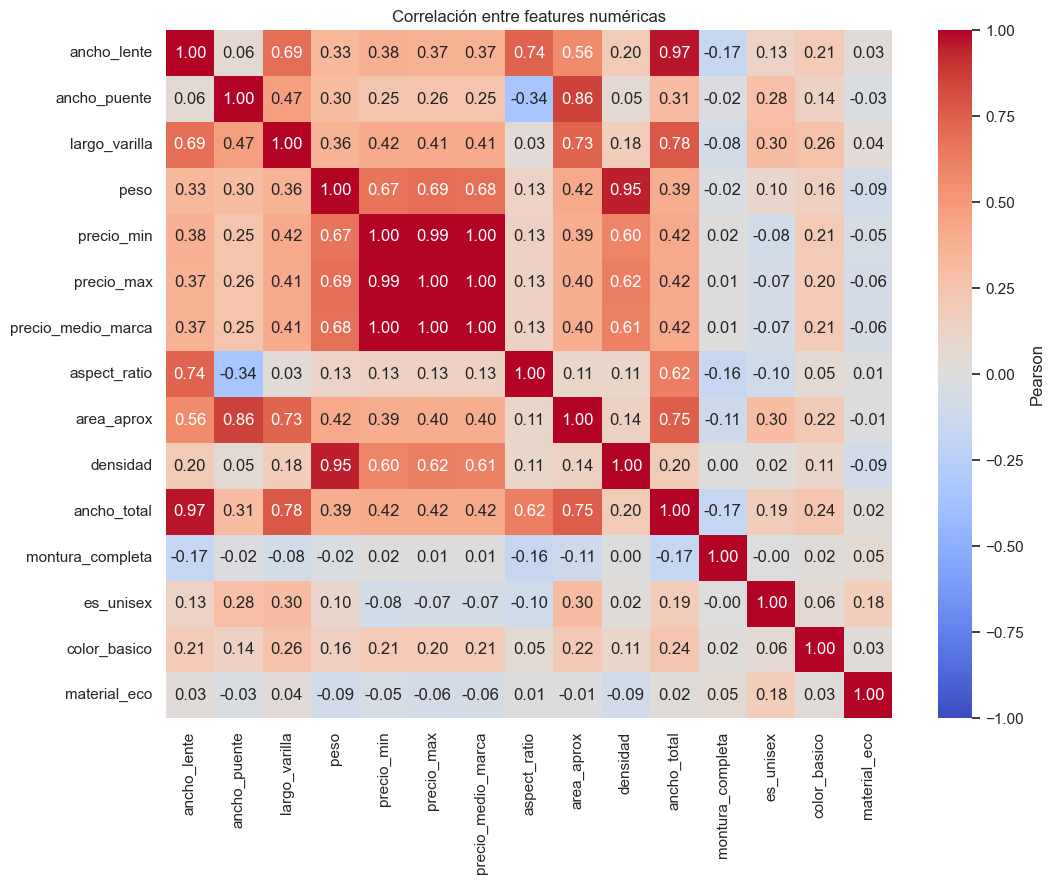

In [17]:
X_num = train_df[NUM_COLS].dropna()
corr = X_num.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson'})
plt.title('Correlación entre features numéricas')
plt.tight_layout()
plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_with_const = add_constant(X_num)
vif = pd.DataFrame({
    'feature': X_with_const.columns,
    'VIF':     [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])],
})
vif = vif[vif['feature'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
vif['flag'] = vif['VIF'].apply(lambda v: '🔴 alta'   if v > 10 else ('🟡 sospechosa' if v > 5 else '🟢 ok'))
vif

,feature,VIF,flag
0,ancho_lente,inf,🔴 alta
1,ancho_puente,inf,🔴 alta
2,precio_min,inf,🔴 alta
3,precio_medio_marca,inf,🔴 alta
4,precio_max,inf,🔴 alta
5,ancho_total,inf,🔴 alta
6,aspect_ratio,425.966666,🔴 alta
7,largo_varilla,388.234487,🔴 alta
8,area_aprox,220.898726,🔴 alta
9,peso,66.678963,🔴 alta


**Decisión basada en VIF + ablaciones:**

Para los modelos lineales finalistas eliminamos las features que aporten poca info y multipliquen colinealidad. Las decisiones concretas se toman en la siguiente sección a la luz de **VIF + bloques A/B/C/D + intuición de negocio**.

## 9. Selección final + GridSearch

**Decisiones tomadas a partir de las ablaciones (sección 7):**

- **Bloque A** → `precio_medio_marca` (descartamos `precio_min` y `precio_max` por redundancia, η² casi idéntica).
- **Bloque B** → medidas originales `ancho_lente` + `ancho_puente` + `largo_varilla` (descartamos `ancho_total`, no aporta información extra).
- **Bloque C** → `peso` (descartamos `densidad` y `area_aprox`, son funciones de las medidas y `peso`).
- **Bloque D** → SIN binarias (`montura_completa`, `es_unisex`, `color_basico`, `material_eco` no movían la métrica).
- **Bonus** → quitamos también `aspect_ratio` (es un cociente de medidas que el modelo de árboles puede recuperar internamente y el lineal apenas usa).

Resultado: 5 features numéricas limpias + las 13 categóricas. Set lean, interpretable y sin multicolinealidad.

In [19]:
NUM_FINAL = existing([
    'ancho_lente',
    'ancho_puente',
    'largo_varilla',
    'peso',
    'precio_medio_marca',
], train_df)
CAT_FINAL = CAT_COLS  # mantenemos todas las categóricas

FEATURES_FINAL = NUM_FINAL + CAT_FINAL
print(f'Features finales ({len(FEATURES_FINAL)}):')
print(f'  num ({len(NUM_FINAL)}): {NUM_FINAL}')
print(f'  cat ({len(CAT_FINAL)}): {CAT_FINAL}')

Features finales (18):
  num (5): ['ancho_lente', 'ancho_puente', 'largo_varilla', 'peso', 'precio_medio_marca']
  cat (13): ['marca', 'genero', 'material_montura', 'forma', 'tipo_montura', 'color', 'talla', 'gama_marca', 'segmento_comercial', 'pais_origen', 'categoria_material', 'gama_material', 'peso_relativo']


In [20]:
X_train_f = train_df[FEATURES_FINAL].copy()
X_test_f  = test_df[FEATURES_FINAL].copy()

# GridSearch para finalista lineal (Ridge sobre log)
lin_pipe = make_linear_pipeline(
    Ridge(random_state=RANDOM_STATE),
    num_cols=NUM_FINAL, cat_cols=CAT_FINAL,
)
param_grid_lin = {'regressor__m__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
gs_lin = GridSearchCV(
    lin_pipe, param_grid_lin,
    cv=KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_absolute_error', n_jobs=-1,
)
gs_lin.fit(X_train_f, y_train)
print(f'Ridge mejor alpha: {gs_lin.best_params_}')
print(f'Ridge MAE en CV:   {-gs_lin.best_score_:.2f} €')

Ridge mejor alpha: {'regressor__m__alpha': 0.1}
Ridge MAE en CV:   20.79 €


In [21]:
# GridSearch para finalista de árboles (RandomForest)
tree_pipe = make_tree_pipeline(
    RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    num_cols=NUM_FINAL, cat_cols=CAT_FINAL,
)
param_grid_tree = {
    'm__n_estimators':     [200, 400],
    'm__max_depth':        [None, 10, 20],
    'm__min_samples_leaf': [1, 2, 5],
    'm__max_features':     ['sqrt', 0.7],
}
gs_tree = GridSearchCV(
    tree_pipe, param_grid_tree,
    cv=KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_absolute_error', n_jobs=-1,
)
gs_tree.fit(X_train_f, y_train)
print(f'RF mejores params:  {gs_tree.best_params_}')
print(f'RF MAE en CV:       {-gs_tree.best_score_:.2f} €')

RF mejores params:  {'m__max_depth': None, 'm__max_features': 0.7, 'm__min_samples_leaf': 1, 'm__n_estimators': 400}
RF MAE en CV:       18.17 €


## 10. Entrenamiento final y evaluación en test

In [22]:
modelo_lineal_final = gs_lin.best_estimator_
modelo_arbol_final  = gs_tree.best_estimator_

y_pred_lineal = modelo_lineal_final.predict(X_test_f)
y_pred_arbol  = modelo_arbol_final.predict(X_test_f)

tabla_test = pd.DataFrame([
    {
        'modelo':  'Ridge (log) — finalista lineal',
        'MAE_€':   mean_absolute_error(y_test, y_pred_lineal),
        'RMSE_€':  rmse(y_test, y_pred_lineal),
        'R²':      r2_score(y_test, y_pred_lineal),
        'MAPE_%':  mape(y_test, y_pred_lineal),
    },
    {
        'modelo':  'RandomForest — finalista árboles',
        'MAE_€':   mean_absolute_error(y_test, y_pred_arbol),
        'RMSE_€':  rmse(y_test, y_pred_arbol),
        'R²':      r2_score(y_test, y_pred_arbol),
        'MAPE_%':  mape(y_test, y_pred_arbol),
    },
]).set_index('modelo').round(2)
tabla_test

,MAE_€,RMSE_€,R²,MAPE_%
modelo,,,,
Ridge (log) — finalista lineal,21.02,30.64,0.81,17.35
RandomForest — finalista árboles,17.78,27.78,0.84,14.75


In [23]:
# Elegir el ganador por MAE
ganador = tabla_test['MAE_€'].idxmin()
print(f'🏆 Modelo final: {ganador}')
if 'lineal' in ganador.lower():
    modelo_final = modelo_lineal_final
    y_pred_final = y_pred_lineal
    nombre_final = 'ridge_log'
else:
    modelo_final = modelo_arbol_final
    y_pred_final = y_pred_arbol
    nombre_final = 'randomforest'

🏆 Modelo final: RandomForest — finalista árboles


In [24]:
# Guardar modelo final
import pickle

out = MODELS_DIR / f'final_model_{nombre_final}.pkl'
with open(out, 'wb') as f:
    pickle.dump(modelo_final, f)

print(f'Modelo guardado en: {out}')

Modelo guardado en: c:\Users\juan_\Desktop\THE-BRIDGE\RepositorioJuanAMM\Proyecto ML\models\final_model_randomforest.pkl


## 11. Diagnósticos e interpretación

### 11a. Real vs predicho + residuos

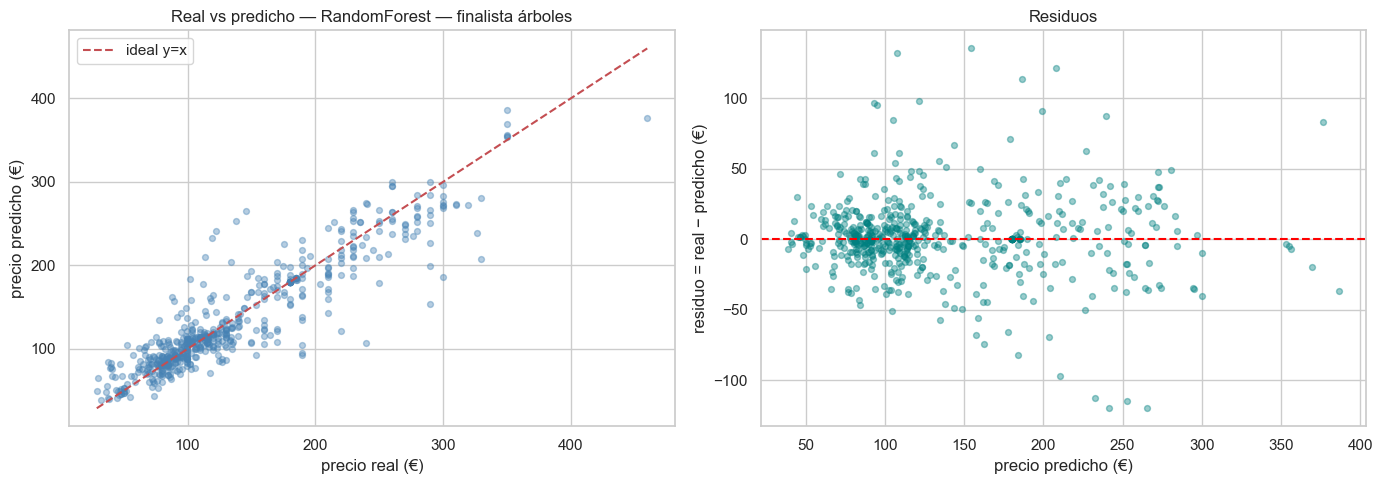

Residuos — media: 1.28 €, std: 27.75 €


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_final, alpha=0.4, s=18, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()),
        max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, 'r--', label='ideal y=x')
axes[0].set_xlabel('precio real (€)')
axes[0].set_ylabel('precio predicho (€)')
axes[0].set_title(f'Real vs predicho — {ganador}')
axes[0].legend()

residuos = y_test.values - y_pred_final
axes[1].scatter(y_pred_final, residuos, alpha=0.4, s=18, color='teal')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('precio predicho (€)')
axes[1].set_ylabel('residuo = real − predicho (€)')
axes[1].set_title('Residuos')

plt.tight_layout()
plt.show()

print(f'Residuos — media: {residuos.mean():.2f} €, std: {residuos.std():.2f} €')

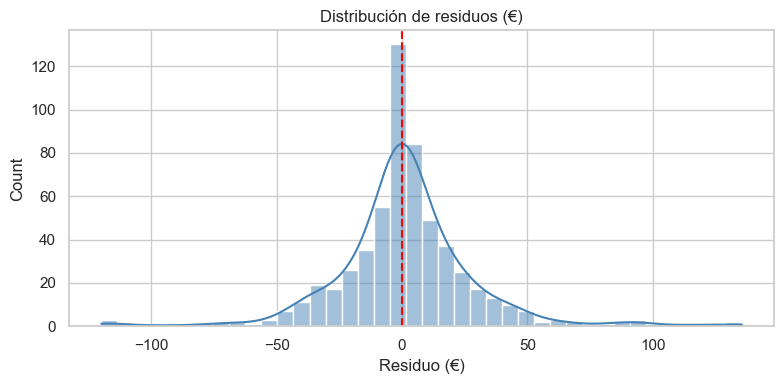

In [26]:
# Distribución de residuos
plt.figure(figsize=(8, 4))
sns.histplot(residuos, bins=40, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de residuos (€)')
plt.xlabel('Residuo (€)')
plt.tight_layout()
plt.show()

### 11b. Permutation importance — modelo de árboles

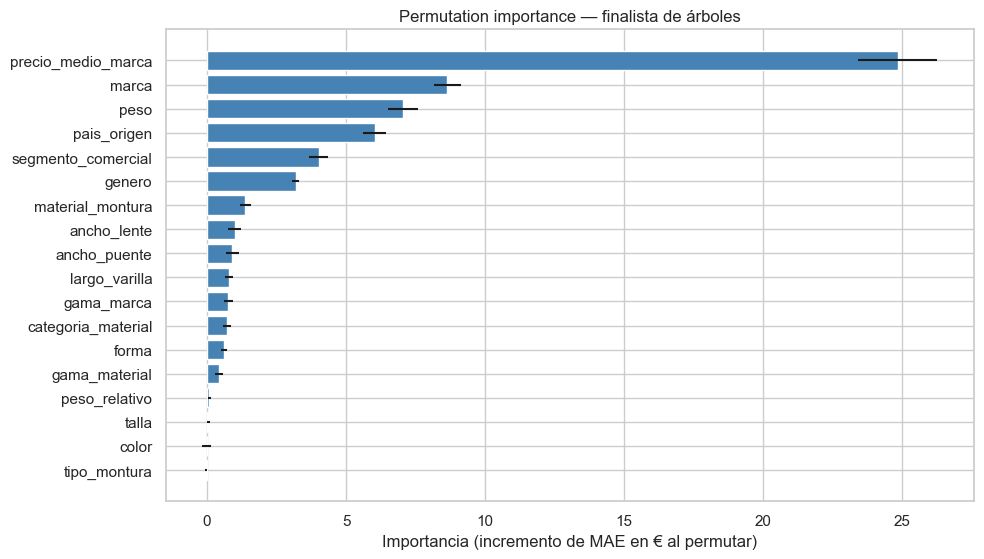

,feature,importance,std
0,precio_medio_marca,24.834,1.426
1,marca,8.641,0.482
2,peso,7.061,0.540
3,pais_origen,6.038,0.414
4,segmento_comercial,4.015,0.346
5,genero,3.189,0.134
6,material_montura,1.375,0.196
7,ancho_lente,0.996,0.235
8,ancho_puente,0.908,0.236
9,largo_varilla,0.786,0.142


In [27]:
perm = permutation_importance(
    modelo_arbol_final, X_test_f, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
    scoring='neg_mean_absolute_error',
)
imp_df = (pd.DataFrame({
    'feature':    X_test_f.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, max(5, 0.32 * len(imp_df))))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        xerr=imp_df['std'][::-1], color='steelblue')
ax.set_xlabel('Importancia (incremento de MAE en € al permutar)')
ax.set_title('Permutation importance — finalista de árboles')
plt.tight_layout()
plt.show()

imp_df.head(10).round(3)

### 11c. Coeficientes — modelo lineal

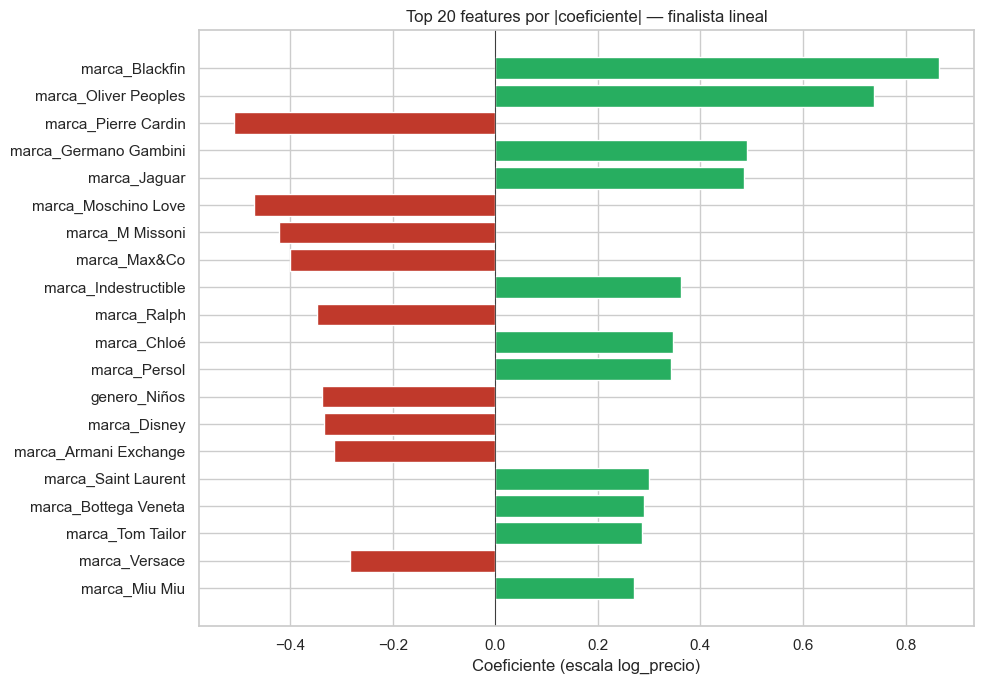

,feature,coef
0,marca_Blackfin,0.865
1,marca_Oliver Peoples,0.738
2,marca_Pierre Cardin,-0.510
3,marca_Germano Gambini,0.491
4,marca_Jaguar,0.485
5,marca_Moschino Love,-0.471
6,marca_M Missoni,-0.422
7,marca_Max&Co,-0.401
8,marca_Indestructible,0.362
9,marca_Ralph,-0.348


In [28]:
inner_pipe = modelo_lineal_final.regressor_
prep_lin   = inner_pipe.named_steps['prep']
ridge      = inner_pipe.named_steps['m']

feat_names = prep_lin.get_feature_names_out()
coef_df = (pd.DataFrame({'feature': feat_names, 'coef': ridge.coef_})
           .assign(abs_coef=lambda d: d['coef'].abs())
           .sort_values('abs_coef', ascending=False)
           .drop(columns='abs_coef')
           .reset_index(drop=True))

top = coef_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#27ae60' if c > 0 else '#c0392b' for c in top['coef'][::-1]]
ax.barh(top['feature'][::-1], top['coef'][::-1], color=colores)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coeficiente (escala log_precio)')
ax.set_title('Top 20 features por |coeficiente| — finalista lineal')
plt.tight_layout()
plt.show()

top.round(3)

## 12. Conclusiones finales

Este proyecto ha permitido construir y comparar distintos modelos para predecir el precio de gafas graduadas a partir de variables físicas, comerciales y de marca. Tras la fase de limpieza, enriquecimiento y selección de variables, se evaluaron dos familias principales de modelos: lineales regularizados sobre `log_precio` y modelos basados en árboles sobre `precio` en euros. Ambos enfoques ofrecieron resultados sólidos, pero el mejor rendimiento final se obtuvo con `RandomForest`, que en test alcanzó `MAE = 17.78 €`, `RMSE = 27.78 €`, `R² = 0.84` y `MAPE = 14.75`. El finalista lineal, `Ridge`, también mostró un comportamiento competitivo (`MAE = 21.02 €`, `R² = 0.81`), lo que confirma que el problema tiene una estructura parcialmente lineal, aunque los árboles capturan mejor relaciones no lineales e interacciones.

Las revisiones y ablaciones realizadas permitieron simplificar el conjunto de features de forma defendible. En el bloque de precio de marca se comprobó que `precio_medio_marca` concentraba prácticamente toda la señal útil, por lo que `precio_min` y `precio_max` se consideraron redundantes. En el bloque geométrico, aunque `ancho_total` resumía bien parte de la información, se decidió conservar `ancho_lente`, `ancho_puente` y `largo_varilla` por interpretabilidad. En el bloque físico, `peso` resultó más útil y estable que `densidad`, y la combinación de ambas apenas mejoró las métricas. Por último, las variables binarias débiles (`montura_completa`, `es_unisex`, `color_basico`, `material_eco`) no aportaron mejora apreciable y se excluyeron del conjunto final.

La revisión de multicolinealidad reforzó estas decisiones. El heatmap y los VIF mostraron redundancias muy fuertes entre `precio_min`, `precio_max` y `precio_medio_marca`, así como entre `ancho_total` y las medidas base, y entre `peso` y `densidad`. Esto confirmó que no era conveniente mantener simultáneamente variables que describían casi la misma información, especialmente en modelos lineales. En cambio, las variables binarias no generaban colinealidad, aunque sí demostraron baja utilidad predictiva.

En cuanto a interpretación, tanto el `RandomForest` como el `Ridge` apuntan a una misma idea general: el precio depende mucho más del posicionamiento comercial de la marca que de la geometría pura de la montura. La permutation importance del modelo ganador mostró que `precio_medio_marca` era la variable más influyente con mucha diferencia, seguida de `marca`, `peso`, `pais_origen` y `segmento_comercial`. El modelo lineal reforzó esta lectura, ya que sus coeficientes de mayor magnitud correspondían sobre todo a dummies de `marca`, lo que indica que la identidad comercial del producto tiene un peso decisivo en la formación del precio.

Como conclusión global, el modelo final es útil, interpretable a nivel de negocio y suficientemente preciso para una primera aplicación predictiva. Para una siguiente iteración, tendría sentido explorar tres líneas de mejora: ampliar el dataset para reducir sesgos de catálogo, incorporar variables más directamente relacionadas con calidad o materiales reales, y probar modelos boosting más ajustados o técnicas de explicación local como SHAP para profundizar en la interpretación de predicciones individuales. Aun así, con los datos disponibles, el resultado final es consistente: el precio de las gafas está explicado en gran medida por la marca y su posicionamiento de mercado, mientras que las medidas físicas aportan señal complementaria pero secundaria.